##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 6 DO LABORATORIUM 1</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Regresja liniowa i logistyczna</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">Regresja logistyczna - wykorzystanie danych z MNIST i tensorflow</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 6

W tym przykładzie zaprezentowane zostanie działanie regresji logistycznej na zbiorze danych MNIST, który zawiera 70 tysięcy obrazków w odcieniach szarości o rozdzielczości 28x28 pikseli, który został zebrany przez Yann’a Lecun (http://yann.lecun.com/exdb/mnist/). Obrazki te zawierają zeskanowane zapisy cyfr: 0-9 co daje to do dyspozycji 10 klas.
Zbiór ten można wczytać na wiele różnych sposobów do projektu, ale żeby uniknąć w tym momencie pewnego preprocessingu skorzystamy z możliwości biblioteki tensorflow.

Do celów aktualnego ćwiczenia przemodelujemy opis klas do problamu binarnego w którym cyfry od 0 do 8 będą stanowić klasę 0, zaś klasę 1 będą stanowić cyfry 9.


In [1]:
# Import podstawowych bibliotek
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import keras
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from io import StringIO
import requests
from random import randint
print(tf.__version__)
print('keras:',keras.__version__)

2.3.0
keras: 2.4.3


W takim rozwiązaniu, zbiór wejściowy jest wczytywany od razu z podziałem na zbiór treningowy (60000) oraz testowy (10000). Zbiór testowy zostanie wykorzystany później do oceny treningu i wyznaczenia miar błędów.

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')

print("Training set size: ", X_train.shape)
print("Test set size: ", X_test.shape)


Training set size:  (60000, 28, 28)
Test set size:  (10000, 28, 28)


Do celów aktualnego ćwiczenia przemodelujemy opis klas, tak aby uzyskać problem binarny, w którym cyfry od 0 do 8 będą stanowić klasę 0, zaś klasę 1 będzie stanowić cyfry 9.

In [3]:
y_train_binary = np.where(y_train < 9, 0.0, 1.0).reshape(y_train.shape[0], 1)
y_train_binary = y_train_binary.astype('float32')

Dane wejściowe potraktujemy jako zbiór cech, stąd "spłaszczamy" reprezentację 2D do reprezentacji 1D (28*28 -> 784).
Taka spłaszczona reprezentacja obrazka przemnożona przez ilość obrazków występujących w rozważanym zbiorze daje nam wektor, który jest łatwiejszy do przetwarzania przez algorytmy uczenia maszynowego. Wartości te zostają również znormalizowane do przedziału [0,1].

In [4]:
#przygotowanie danych treningowych jako wektor znormalizowany
X_train_flat = X_train.reshape((X_train.shape[0], X_train.shape[1]*X_train.shape[2]))
X_train_flat = X_train_flat.astype('float32')/255.0
print("Input dataset shape: ", X_train_flat.shape)

#przygotowanie danych testowych jako wektor znormalizowany
y_test_binary = np.where(y_test < 9, 0.0, 1.0).reshape(y_test.shape[0], 1)
y_test_binary = y_test_binary.astype('float32').flatten()
X_test_flat = X_test.reshape((X_test.shape[0], X_test.shape[1]*X_test.shape[2]))
X_test_flat = X_test_flat.astype('float32')/255.0
print("Test dataset shape: ", X_test_flat.shape)

Input dataset shape:  (60000, 784)
Test dataset shape:  (10000, 784)


Przykładowy obraz z bazy danych, jego oryginalna etykieta oraz aktualna przynależność do klasy zostały przedstawione w poniższej sekcji.

True orginal label : 9
True binary label : [1.]


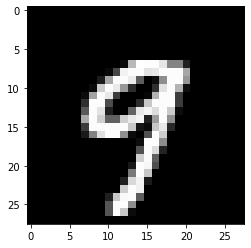

In [5]:
example = randint(0, 100)
plt.imshow(X_train[example], cmap="gray")
print("True orginal label :", y_train[example])
print("True binary label :", y_train_binary[example])

W tym kroku dopasowujemy model regresji logistycznej do "spłaszczonych" danych wejściowych oraz zaprezentowany zostanie wynik predykcji dla zbioru danych testowych

In [7]:
model = LogisticRegression(solver='newton-cg',random_state=0).fit(X_train_flat, y_train_binary.flatten())

print("Wynik ewaluacji wytrenowanego modelu: ",model.score(X_test_flat, y_test_binary.flatten()))

Wynik ewaluacji wytrenowanego modelu:  0.9674


c:\users\tomas\ella\lib\site-packages\scipy\optimize\linesearch.py:327: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
c:\users\tomas\ella\lib\site-packages\sklearn\utils\optimize.py:195: UserWarning: Line Search failed
  warnings.warn('Line Search failed')


Mając wytrenowany model można go użyć do oceny prognozy $p$ innego wektora wejściowego.

Wartość prognozy dla wybranego przypadku:  [1.]
Prawdziwa etykieta klasy dla wybranego przypadku:  1
Przewidywana etykieta klasy dla wybranego przypadku:  1


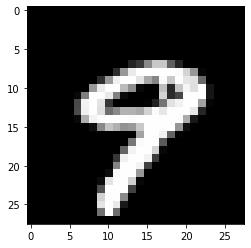

In [8]:
test_example = 9
p = model.predict(X_test_flat[test_example:test_example+1])

# Wyswietlenie wartości prognozy ("prawdopodobieństwa") p z przedziału [0,1]
print("Wartość prognozy dla wybranego przypadku: ", p)
print("Prawdziwa etykieta klasy dla wybranego przypadku: ", int(y_test_binary[test_example]))

# Użycie wartości progu w celu przypisania do odpowiednich klas 
predicted_class = 0 if p < 0.5 else 1
print("Przewidywana etykieta klasy dla wybranego przypadku: ", predicted_class)

plt.imshow(X_test[test_example], cmap="gray")

# Zadania do wykonania

<p><b>Zadanie 1</b></p>
Przeprowadź eksperyment, przy którym będzie inne przyporządkowanie do klas i przedstaw uzyskane wyniki zgodnie z zaleceniami prowadzącego.

![stopka.svg](stopka.svg)